In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [15]:
from src.load_sam_data import load_dataset
dataset = load_dataset("..\\data\\FJ\\FI01X1\\FI01X1_ch")
dataset = np.array(dataset)

In [184]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
dataset = scaler.fit_transform(dataset)

In [ ]:
# EXPERIMENTS
"""
import torch.nn as nn

encoder = nn.Sequential(
    nn.Conv1d(1, 8, kernel_size=6, stride=2, padding=1),  # output: feats, 47
    #nn.BatchNorm1d(8),
    nn.ReLU(),
    nn.Conv1d(8, 16, kernel_size=6, stride=2, padding=1), # output: feats, 22
    #nn.BatchNorm1d(16),
)

decoder = nn.Sequential(
    nn.ConvTranspose1d(16, 8, kernel_size=4, stride=2, padding=1),  # output: feats, 46
    #nn.BatchNorm1d(8),
    nn.ReLU(),
    nn.ConvTranspose1d(8, 1, kernel_size=6, stride=2, padding=1),  # output: feats, 94
    #nn.BatchNorm1d(1),
    nn.Linear(94, 96),
    nn.Sigmoid()
)

import torch 

torch_df = torch.from_numpy(dataset)
torch_df = torch_df.to(torch.float32)

pt = torch_df[0]

conv = nn.Conv1d(1, 1, kernel_size=6, stride=2, padding=1)
conv2 = nn.Conv1d(1, 1, kernel_size=6, stride=2, padding=1)
out = conv(pt.reshape(1,1,96))
out = conv2(out)
out = nn.ConvTranspose1d(1, 1, kernel_size=4, stride=2)(out)
out = nn.ConvTranspose1d(1, 1, kernel_size=6, stride=2)(out)
out.shape"""

torch.Size([1, 1, 96])

In [228]:
import torch.nn as nn

# first model
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 1, kernel_size=6, stride=2, padding=1),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            nn.Conv1d(1, 1, kernel_size=6, stride=2, padding=1), 
            nn.BatchNorm1d(1),
            nn.Sigmoid()
            )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(1, 1, kernel_size=4, stride=2),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            nn.ConvTranspose1d(1, 1, kernel_size=6, stride=2),
            nn.BatchNorm1d(1),
            nn.Sigmoid()
            )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [229]:
import torch 

torch_df = torch.from_numpy(dataset)
torch_df = torch_df.to(torch.float32)

In [206]:
from torch.utils.data import Dataset, DataLoader

class HistDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        x = self.df[idx]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        
        x = x.unsqueeze(0)
        return x

In [230]:
batch_size = 32
torch_small_df = HistDataset(torch_df)
dataloader = DataLoader(torch_small_df, batch_size=batch_size, shuffle=False)

In [235]:
ae_conv = Autoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=ae_conv.parameters(), lr=0.002)

In [236]:
# first model training loop
losses = []
n_epochs = 40
ae_conv.train()

for e in range(n_epochs):
    for pt in dataloader:
        #pt = pt.reshape(batch_size, 1, 96)
        recreated = ae_conv(pt)
        loss = criterion(pt, recreated)
        loss.backward()
        optimizer.step()
    losses.append(loss.detach().numpy())

    #print(f'Epoch: {e} | Loss: {loss.detach().numpy()}')  

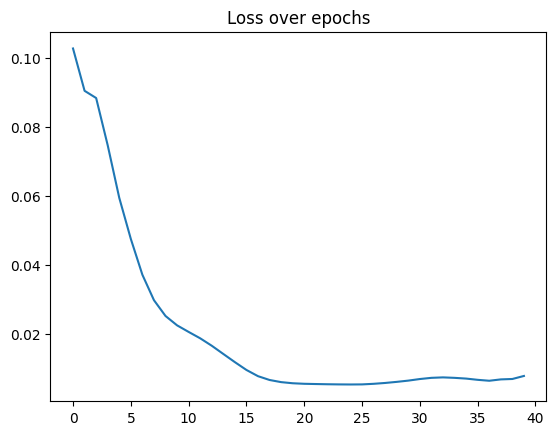

In [237]:
plt.title('Loss over epochs')
plt.plot(range(len(losses)), losses)

c:\Users\hrdyj\coding\vyzkumak\mlenv\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([1, 96])) that is different to the input size (torch.Size([1, 1, 96])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


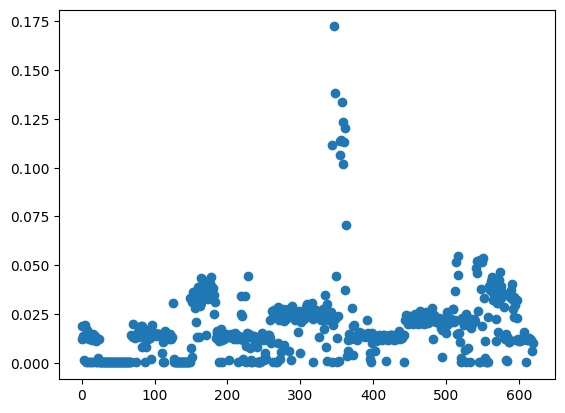

In [238]:
ae_conv.eval()
score = []
for batch in dataloader:
    for pt in batch:
        loss = criterion(ae_conv(pt.unsqueeze(0)), pt)
        score.append(loss.detach().numpy())

plt.scatter(range(len(score)), score)
plt.show()

In [191]:
top_scores = sorted(score)[-3:]
for s in top_scores:
    print(score.index(s))

354
357
346


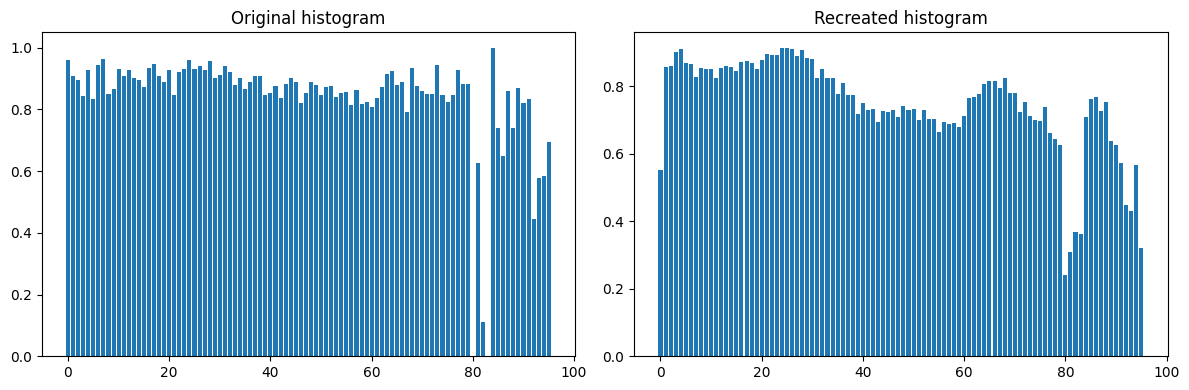

In [ ]:
idx = 343
pred = ae_conv(torch_small_df[idx].unsqueeze(0))
pred = pred.detach().numpy().squeeze()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), dataset[idx])
axes[0].set_title("Original histogram")

axes[1].bar(range(len(pred)), pred)
axes[1].set_title("Recreated histogram")


plt.tight_layout()
plt.show()